In [2]:
import os
import numpy as np
import pandas as pd
from sklearn import metrics
import matplotlib.pyplot as plt

In [3]:
start_year = 2004
end_year = 2009
# pred_file = f'../results/{start_year}-{end_year}/hdpsm_nrep10_mratio5_maxsamp50000_drug_reaction_associations.csv'
pred_file = '../data/OFFSIDES.csv.gz'

In [26]:
# float_cols = {'A': float, 'B':float, 'C':float, 'D':float, 'PRR':float, 'PRR_error':float, 'mean_reporting_frequency':float}
preds = pd.read_csv(pred_file)
# Ensure columns used in mean calculation are float
for col in ['A', 'B']:
    preds[col] = pd.to_numeric(preds[col], errors='coerce')

preds = preds[preds.A >= 5]
preds.head()

/tmp/ipykernel_291174/1354456875.py:2: DtypeWarning: Columns (0,2,4,5,6,7,8,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  preds = pd.read_csv(pred_file)


,drug_rxnorn_id,drug_concept_name,condition_meddra_id,condition_concept_name,A,B,C,D,PRR,PRR_error,mean_reporting_frequency
0,4024,"ergoloid mesylates, USP",10002034,Anaemia,6.0,126.0,21,1299,2.85714,0.45382,0.045455
9,4024,"ergoloid mesylates, USP",10007515,Cardiac arrest,6.0,126.0,19,1301,3.15789,0.459309,0.045455
10,4024,"ergoloid mesylates, USP",10007617,Cardio-respiratory arrest,5.0,127.0,15,1305,3.33333,0.508265,0.037879
11,4024,"ergoloid mesylates, USP",10042434,Sudden death,6.0,126.0,6,1314,10.0,0.570088,0.045455
13,4024,"ergoloid mesylates, USP",10013573,Dizziness,23.0,109.0,66,1254,3.48485,0.224269,0.174242


In [27]:

preds['reaction'] = preds['condition_concept_name'].str.lower()
preds['drug'] = preds['drug_concept_name'].str.lower()
preds['mean'] = preds['A']/(preds['A']+preds['B'])
preds = preds.dropna()
preds.head()

,drug_rxnorn_id,drug_concept_name,condition_meddra_id,condition_concept_name,A,B,C,D,PRR,PRR_error,mean_reporting_frequency,reaction,drug,mean
0,4024,"ergoloid mesylates, USP",10002034,Anaemia,6.0,126.0,21,1299,2.85714,0.45382,0.045455,anaemia,"ergoloid mesylates, usp",0.045455
9,4024,"ergoloid mesylates, USP",10007515,Cardiac arrest,6.0,126.0,19,1301,3.15789,0.459309,0.045455,cardiac arrest,"ergoloid mesylates, usp",0.045455
10,4024,"ergoloid mesylates, USP",10007617,Cardio-respiratory arrest,5.0,127.0,15,1305,3.33333,0.508265,0.037879,cardio-respiratory arrest,"ergoloid mesylates, usp",0.037879
11,4024,"ergoloid mesylates, USP",10042434,Sudden death,6.0,126.0,6,1314,10.0,0.570088,0.045455,sudden death,"ergoloid mesylates, usp",0.045455
13,4024,"ergoloid mesylates, USP",10013573,Dizziness,23.0,109.0,66,1254,3.48485,0.224269,0.174242,dizziness,"ergoloid mesylates, usp",0.174242


In [28]:
# positive controls
# fn = '../data/onsides_public_warnings_and_precautions.csv'
# positive_df = pd.read_csv(fn)
# positive_df['pt_meddra_term'] = positive_df['pt_meddra_term'].str.lower()
# positive_df.rename(columns={'pt_meddra_term': 'reaction', 'ingredients_names': 'drug'}, inplace=True)
# positive_df['label'] = 1
# positive_df.head()

fn = '../data/onsides_v3_0_0_high_confidence_mapped.csv'
positive_df = pd.read_csv(fn)
positive_df['meddra_name'] = positive_df['meddra_name'].str.lower()
positive_df.rename(columns={'meddra_name': 'reaction', 'rxnorm_name': 'drug'}, inplace=True)
positive_df['label'] = 1
positive_df.head()

,rxnorm_id,drug,meddra_id,reaction,label
0,10580,thyrotropin-releasing hormone,10019211,headache,1
1,34530,procaterol,10047700,vomiting,1
2,7880,pancreatin,10034966,photosensitivity,1
3,90120,Magnesium salt,10010300,confusion,1
4,9863,sodium chloride,10013781,dry mouth,1


In [29]:
# merged = pd.merge(preds, positive_df, on=['drug', 'reaction'], how='left')
# merged = merged[merged['replicate']==1]
# merged['label'] = merged['label'].fillna(0)
# merged.head()

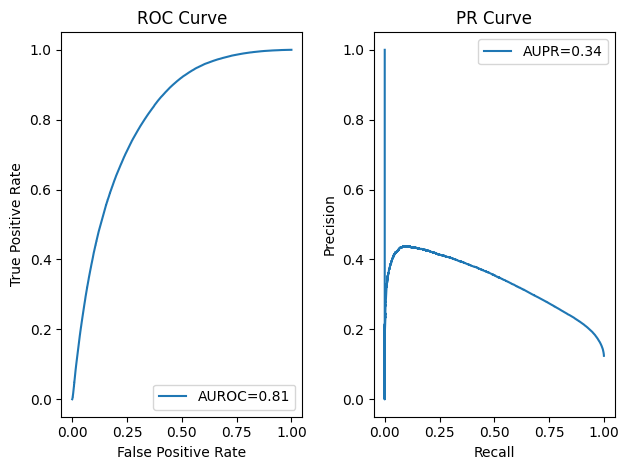

In [30]:
col = 'mean'
rep = 1

merged = pd.merge(preds, positive_df, on=['drug', 'reaction'], how='left')
# merged = merged[merged['replicate']==rep]
merged['label'] = merged['label'].fillna(0)

auroc = metrics.roc_auc_score(merged['label'], merged[col])
aupr = metrics.average_precision_score(merged['label'], merged[col])
fpr, tpr, thresholds = metrics.roc_curve(merged['label'], merged[col], pos_label=1)
plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f"AUROC={auroc:.2f}")
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

pr, re, th = metrics.precision_recall_curve(merged['label'], merged[col])
plt.subplot(1,2,2)
plt.plot(re, pr, label=f"AUPR={aupr:.2f}")
plt.title('PR Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')

plt.legend()
plt.tight_layout()
plt.savefig(f'../results/{start_year}-{end_year}/offsides_v1_performance_roc_pr_curves_onsides.pdf')


In [31]:
neg = merged[col][merged['label']==0]
pos = merged[col][merged['label']==1]
len(neg), len(pos), neg.mean(), pos.mean()

(927437, 131641, 0.0038957691692517254, 0.013107312548888207)